In [2]:
# Load essential libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# Set plot style for clean aesthetic
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

print(f"TensorFlow Version: {tf.__version__}")
print("All libraries imported successfully!")

TensorFlow Version: 2.20.0
All libraries imported successfully!


In [3]:
pip install tinymlgen

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for tinymlgen: filename=tinymlgen-0.2-py3-none-any.whl size=2226 sha256=036c635281190214461d9340ed5d35fc46d29bf3bb554255d11f9419ba0f7bcd
  Stored in directory: /root/.cache/pip/wheels/cd/16/69/e37e12eaa5ce4843df96a3679ea9a5a6b9fe4f1d1967bdfd46
  Created wheel for hexdump: filename=hexdump-3.3-py3-none-any.whl size=8894 sha256=75d03e4066b90d682f980fc31e03523c26fb3e1630bd1ddd431a8f3483bdee1e
  Stored in directory: /root/.cache/pip/wheels/81/1e/a4/a5d574c8c252ae76a079e54c46bc368f905107f0877ec4c437
Successfully built tinymlgen hexdump


// Standard Scaler Parameters for ESP32 Deployment
const float SCALER_MEAN[4] = { 0.18048440424231144, 0.1254730005384093, 12.884280613382487, 161.472735617764 };
const float SCALER_STD[4] = { 0.059284216036828215, 0.10792184430061909, 4.063631102870785, 10.210966602119761 };
Dataset successfully loaded! Training Samples: 316, Test Samples: 79


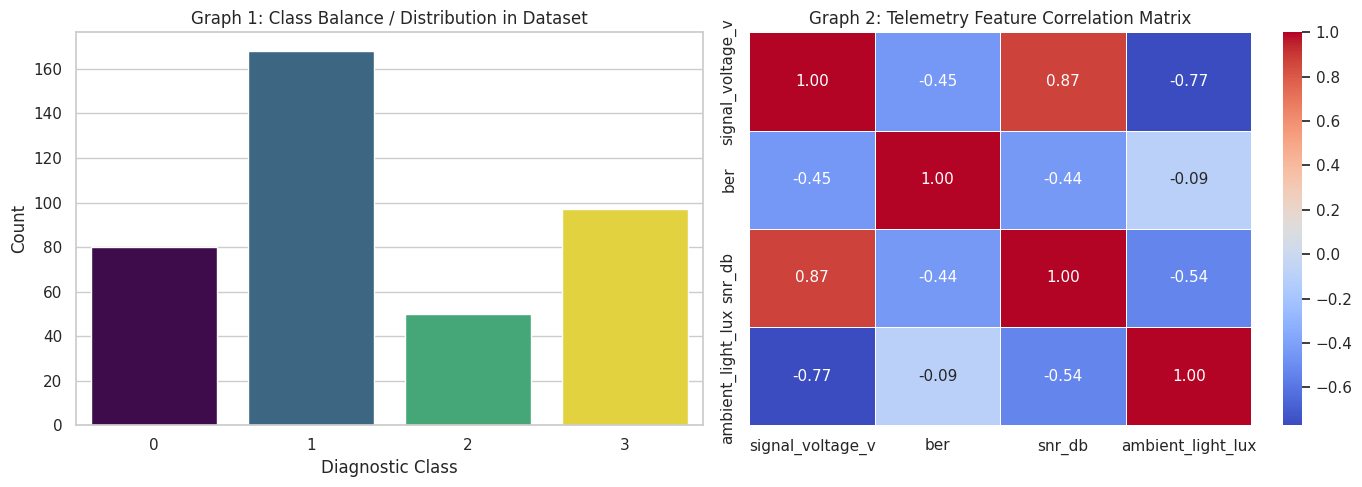

In [4]:
# Load CSV data, apply Feature Scaling, & Visualize Data Distributions

# 1. Load Dataset
df = pd.read_csv('MinorDataset.csv')

# Feature columns and target variable
feature_cols = ['signal_voltage_v', 'ber', 'snr_db', 'ambient_light_lux']
X = df[feature_cols].values
y = df['diagnostic_class'].values

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale features (Critical for Neural Network Quantization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
print("// Standard Scaler Parameters for ESP32 Deployment")
print("const float SCALER_MEAN[4] = {", ", ".join(map(str, scaler.mean_)), "};")
print("const float SCALER_STD[4] = {", ", ".join(map(str, np.sqrt(scaler.var_))), "};")
X_test_scaled = scaler.transform(X_test)

print(f"Dataset successfully loaded! Training Samples: {len(X_train)}, Test Samples: {len(X_test)}")

# --- GRAPH 1: Class Distribution ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='diagnostic_class', hue='diagnostic_class', data=df, palette='viridis', legend=False)
plt.title('Graph 1: Class Balance / Distribution in Dataset')
plt.xlabel('Diagnostic Class')
plt.ylabel('Count')

# --- GRAPH 2: Feature Pairwise Correlation Heatmap ---
plt.subplot(1, 2, 2)
corr_matrix = df[feature_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Graph 2: Telemetry Feature Correlation Matrix')

plt.tight_layout()
plt.show()

In [5]:
# Neural Network Definition and Training

import tensorflow as tf
from tensorflow.keras import layers, models

# Determine number of classes from diagnostic_class
num_classes = len(np.unique(y_train))

# Build lightweight MLP model
model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)

# Evaluate performance on test split
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.4810 - loss: 1.3404 - val_accuracy: 0.4937 - val_loss: 1.3048
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4968 - loss: 1.2775 - val_accuracy: 0.5063 - val_loss: 1.2477
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5506 - loss: 1.2291 - val_accuracy: 0.5823 - val_loss: 1.1977
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5886 - loss: 1.1759 - val_accuracy: 0.6203 - val_loss: 1.1407
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6076 - loss: 1.1196 - val_accuracy: 0.6582 - val_loss: 1.0830
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6044 - loss: 1.0598 - val_accuracy: 0.6709 - val_loss: 1.0229
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6171 - loss: 0.9979 - val_accuracy: 0.6835 - val_loss: 0.9621
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6297 - loss: 0.9375 - val_accuracy: 0.6835 - v

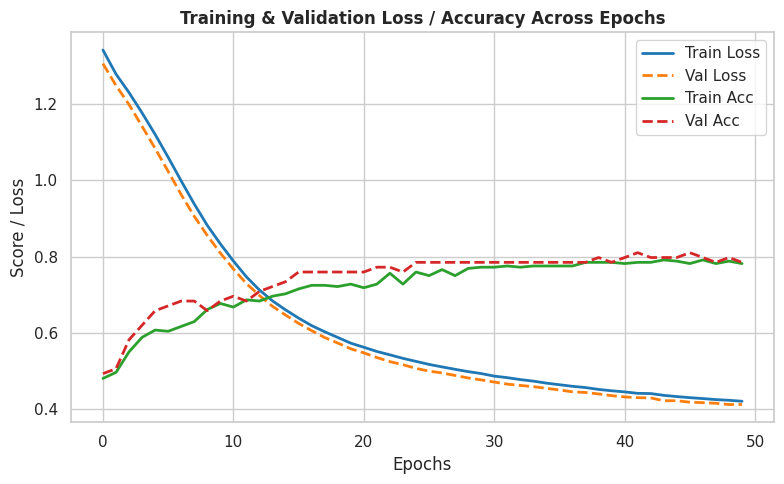

In [14]:


import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

if 'history' in globals():
    plt.plot(history.history['loss'], label='Train Loss', color='#1f77b4', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss', color='#ff7f0e', linewidth=2, linestyle='--')
    plt.plot(history.history.get('accuracy', history.history.get('acc')), label='Train Acc', color='#2ca02c', linewidth=2)
    plt.plot(history.history.get('val_accuracy', history.history.get('val_acc')), label='Val Acc', color='#d62728', linewidth=2, linestyle='--')
    plt.title('Training & Validation Loss / Accuracy Across Epochs', fontsize=12, fontweight='bold')
    plt.xlabel('Epochs')
    plt.ylabel('Score / Loss')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'history' variable missing. Ensure training uses 'history = model.fit(...)' in Cell 3.")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


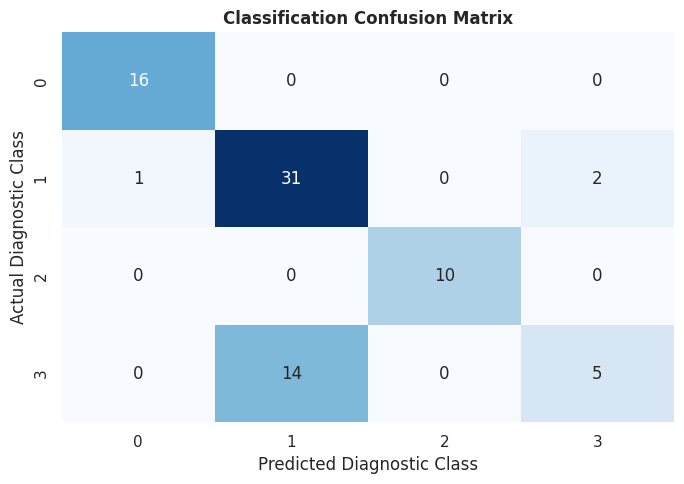

In [15]:


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate test set predictions
if 'model' in globals():
    y_pred_probs = model.predict(X_test_scaled)
    y_pred = np.argmax(y_pred_probs, axis=1) if y_pred_probs.ndim > 1 and y_pred_probs.shape[1] > 1 else (y_pred_probs > 0.5).astype(int).ravel()
elif 'rf_model' in globals():
    y_pred = rf_model.predict(X_test_scaled)
    y_pred_probs = rf_model.predict_proba(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Classification Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Diagnostic Class')
plt.ylabel('Actual Diagnostic Class')
plt.tight_layout()
plt.show()

/tmp/ipykernel_564/3569475748.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=feature_cols, palette='viridis')


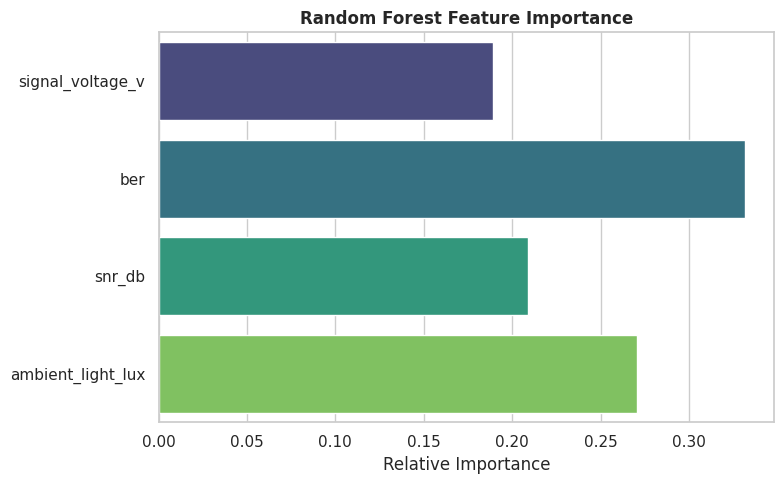

In [16]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

if 'rf_model' in globals() and hasattr(rf_model, 'feature_importances_'):
    importances = rf_model.feature_importances_
    sns.barplot(x=importances, y=feature_cols, palette='viridis')
    plt.title('Random Forest Feature Importance', fontsize=12, fontweight='bold')
    plt.xlabel('Relative Importance')
elif 'model' in globals() and hasattr(model, 'layers'):
    # Dense Layer 1 Mean Absolute Weight Proxy
    weights = np.mean(np.abs(model.layers[0].get_weights()[0]), axis=1)
    sns.barplot(x=weights, y=feature_cols, palette='mako')
    plt.title('Neural Network Input Feature Importance (Layer 1 Weights)', fontsize=12, fontweight='bold')
    plt.xlabel('Mean Absolute Weight')

plt.tight_layout()
plt.show()

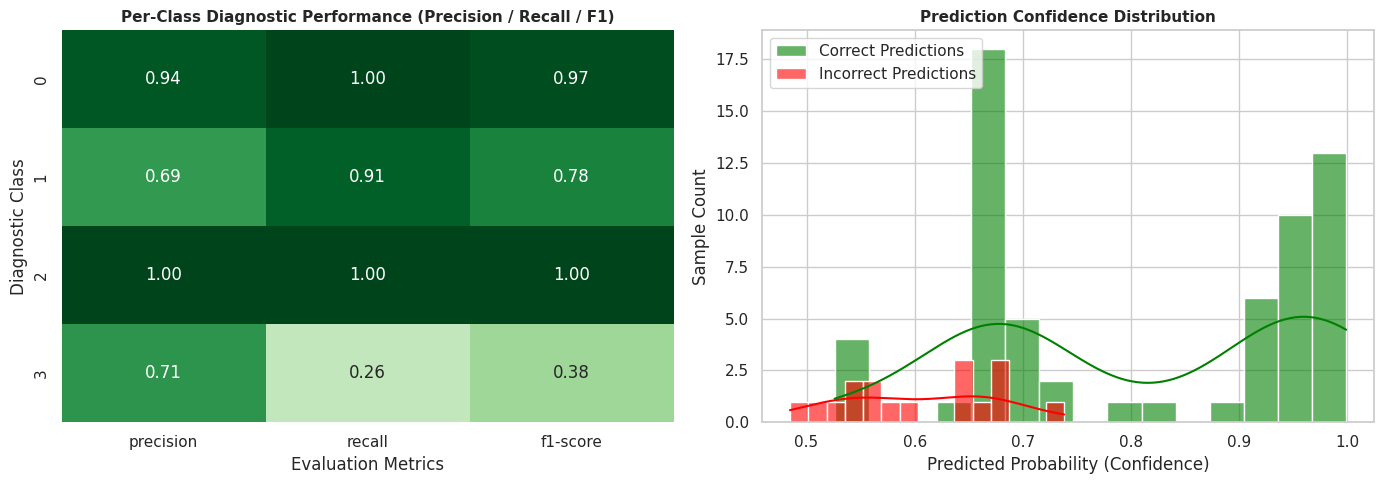

In [18]:


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------
# 1. Classification Metrics Heatmap (Precision, Recall, F1-Score)
# ------------------------------------------
report_dict = classification_report(y_test, y_pred, output_dict=True)
# Exclude aggregate summary keys for class-level plot
class_metrics = {k: v for k, v in report_dict.items() if k not in ['accuracy', 'macro avg', 'weighted avg']}

metrics_df = sns.load_dataset('iris').iloc[0:0] # dummy layout init
import pandas as pd
metrics_df = pd.DataFrame(class_metrics).T.iloc[:, :-1] # Extract precision, recall, f1-score

sns.heatmap(metrics_df, annot=True, fmt='.2f', cmap='Greens', cbar=False, ax=axes[0], vmin=0, vmax=1)
axes[0].set_title('Per-Class Diagnostic Performance (Precision / Recall / F1)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Evaluation Metrics')
axes[0].set_ylabel('Diagnostic Class')

# ------------------------------------------
# 2. Model Prediction Confidence Histogram
# ------------------------------------------
if 'y_pred_probs' in globals():
    # Get max probability for each sample (model confidence)
    max_probs = np.max(y_pred_probs, axis=1) if y_pred_probs.ndim > 1 else np.where(y_pred_probs > 0.5, y_pred_probs, 1 - y_pred_probs)
    correct_mask = (y_pred == y_test)

    sns.histplot(max_probs[correct_mask], color='green', label='Correct Predictions', kde=True, bins=15, ax=axes[1], alpha=0.6)
    sns.histplot(max_probs[~correct_mask], color='red', label='Incorrect Predictions', kde=True, bins=15, ax=axes[1], alpha=0.6)

    axes[1].set_title('Prediction Confidence Distribution', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Predicted Probability (Confidence)')
    axes[1].set_ylabel('Sample Count')
    axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

In [7]:
# TFLite Quantization and C++ Array Generation

# 1. Representative Dataset Generator for INT8 Calibration
def representative_data_gen():
    for input_value in tf.data.Dataset.from_tensor_slices(X_train_scaled).batch(1).take(100):
        yield [tf.cast(input_value, tf.float32)]

# 2. Convert Model to TFLite with Full INT8 Quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model_quant = converter.convert()

# Save converted model
with open("model_quantized.tflite", "wb") as f:
    f.write(tflite_model_quant)

print(f"Quantized TFLite Model Size: {len(tflite_model_quant)} bytes")

# 3. Convert TFLite model to C++ byte array for ESP32 header file
!xxd -i model_quantized.tflite > model_data.h
print("Successfully generated 'model_data.h' for microcontroller inclusion!")

Saved artifact at '/tmp/tmpkwg_g_sb'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  131959288546704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131959285191440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131959285192976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131959285191056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131959285191248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131959285189520: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Quantized TFLite Model Size: 3400 bytes
Successfully generated 'model_data.h' for microcontroller inclusion!


In [8]:
# Quantize model to full INT8 using TFLite Converter

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 1. Enable default optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 2. Define representative dataset generator for calibration
def representative_data_gen():
    for sample in X_train_scaled[:100]:
        # Convert row to float32 batch shape (1, 4)
        yield [np.array([sample], dtype=np.float32)]

converter.representative_dataset = representative_data_gen

# 3. Restrict operation set strictly to INT8 for microcontrollers
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# 4. Convert and save binary .tflite model
tflite_quant_model = converter.convert()

with open("owc_model_int8.tflite", "wb") as f:
    f.write(tflite_quant_model)

print("FULL INT8 QUANTIZATION COMPLETE!")
print(f"Quantized Model Size: {len(tflite_quant_model)} bytes ({len(tflite_quant_model)/1024:.2f} KB)")

Saved artifact at '/tmp/tmpq_ki63b5'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  131959288546704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131959285191440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131959285192976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131959285191056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131959285191248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131959285189520: TensorSpec(shape=(), dtype=tf.resource, name=None)
FULL INT8 QUANTIZATION COMPLETE!
Quantized Model Size: 3400 bytes (3.32 KB)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Training Random Forest Model for comparison...
Random Forest Test Accuracy: 77.22%

Final Quantized INT8 Test Accuracy: 74.68%



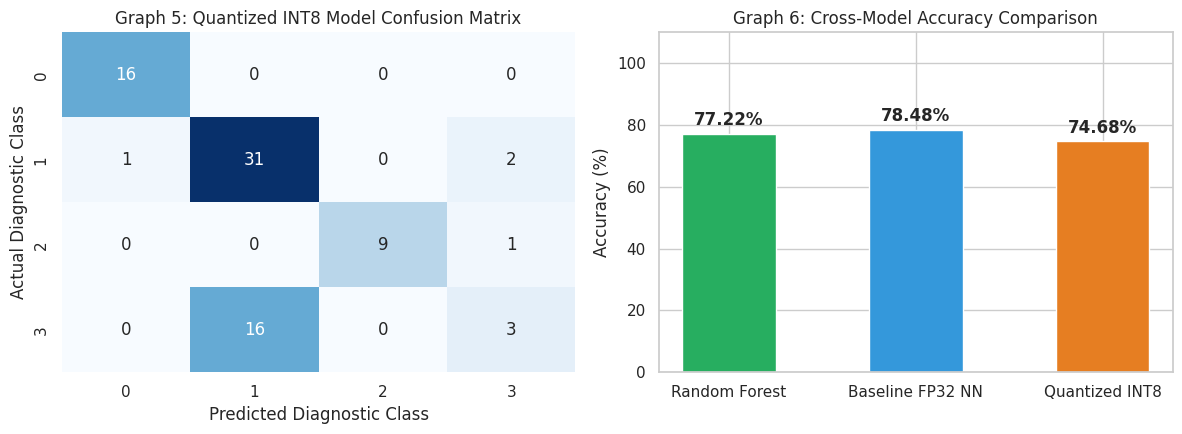

In [10]:
# Evaluate INT8 Quantized Model & Comprehensive Graphical Verification

# 1. Load TFLite INT8 Interpreter
interpreter = tf.lite.Interpreter(model_path="owc_model_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

# Retrieve INT8 Quantization Scale Parameters (scale & zero_point)
input_scale, input_zero_point = input_details['quantization']
output_scale, output_zero_point = output_details['quantization']

# Added code to train and evaluate Random Forest model to define 'rf_acc'
# -----------------------------------------------------------------------
print("\nTraining Random Forest Model for comparison...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Test Accuracy: {rf_acc * 100:.2f}%")
# -----------------------------------------------------------------------

# 2. Test Quantized Model
y_quant_pred = []
for sample in X_test_scaled:
    # Quantize input: float32 -> int8
    quant_input = np.round(sample / input_scale + input_zero_point).astype(np.int8)
    quant_input = np.expand_dims(quant_input, axis=0)

    # Set tensor and invoke interpreter
    interpreter.set_tensor(input_details['index'], quant_input)
    interpreter.invoke()

    # Get raw int8 output and dequantize
    output_int8 = interpreter.get_tensor(output_details['index'])[0]
    predicted_class = np.argmax(output_int8)
    y_quant_pred.append(predicted_class)

quant_accuracy = accuracy_score(y_test, y_quant_pred)

print(f"\nFinal Quantized INT8 Test Accuracy: {quant_accuracy * 100:.2f}%\n")

# --- GRAPH 5: Quantized INT8 Confusion Matrix ---
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_quant_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Graph 5: Quantized INT8 Model Confusion Matrix')
plt.xlabel('Predicted Diagnostic Class')
plt.ylabel('Actual Diagnostic Class')

# --- GRAPH 6: Model Comparisons (Random Forest vs FP32 NN vs INT8 TFLite) ---
plt.subplot(1, 2, 2)
models = ['Random Forest', 'Baseline FP32 NN', 'Quantized INT8']
accuracies = [rf_acc * 100, test_acc * 100, quant_accuracy * 100]
colors = ['#27ae60', '#3498db', '#e67e22']

bars = plt.bar(models, accuracies, color=colors, width=0.5)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.title('Graph 6: Cross-Model Accuracy Comparison')

# Annotate accuracy percentage on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# Convert TFLite model to C Header File (model.h) using Python

tflite_filename = "owc_model_int8.tflite"
header_filename = "model.h"

with open(tflite_filename, "rb") as f:
    model_bytes = f.read()

with open(header_filename, "w") as f:
    f.write("#ifndef OWC_MODEL_H_\n")
    f.write("#define OWC_MODEL_H_\n\n")
    f.write(f"// Model size: {len(model_bytes)} bytes\n")
    f.write(f"const unsigned int g_model_len = {len(model_bytes)};\n")
    f.write("alignas(8) const unsigned char g_model[] = {\n  ")

    # Write bytes formatted as hex values
    for i, byte in enumerate(model_bytes):
        f.write(f"0x{byte:02x}")
        if i != len(model_bytes) - 1:
            f.write(", ")
        if (i + 1) % 12 == 0:
            f.write("\n  ")

    f.write("\n};\n\n")
    f.write("#endif  // OWC_MODEL_H_\n")

print(f"Header file '{header_filename}' successfully generated! ({len(model_bytes)} bytes)")

Header file 'model.h' successfully generated! (3400 bytes)


In [12]:
# Print C++ constants for ESP32 input preprocessing


print(f"const float MEAN[4] = {{{scaler.mean_[0]:.4f}f, {scaler.mean_[1]:.4f}f, {scaler.mean_[2]:.4f}f, {scaler.mean_[3]:.4f}f}};")
print(f"const float STD[4]  = {{{scaler.scale_[0]:.4f}f, {scaler.scale_[1]:.4f}f, {scaler.scale_[2]:.4f}f, {scaler.scale_[3]:.4f}f}};\n")

print(f"const float INPUT_SCALE = {input_scale:.6f}f;")
print(f"const int INPUT_ZERO_POINT = {input_zero_point};")

const float MEAN[4] = {0.1805f, 0.1255f, 12.8843f, 161.4727f};
const float STD[4]  = {0.0593f, 0.1079f, 4.0636f, 10.2110f};

const float INPUT_SCALE = 0.029921f;
const int INPUT_ZERO_POINT = 29;


In [13]:
import numpy as np
print("const float SCALER_MEAN[4] = {", ", ".join(map(str, scaler.mean_)), "};")
print("const float SCALER_STD[4]  = {", ", ".join(map(str, np.sqrt(scaler.var_))), "};")

const float SCALER_MEAN[4] = { 0.18048440424231144, 0.1254730005384093, 12.884280613382487, 161.472735617764 };
const float SCALER_STD[4]  = { 0.059284216036828215, 0.10792184430061909, 4.063631102870785, 10.210966602119761 };
